In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import wandb
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import plot_tree

c:\Users\matth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- LOGIN & INITIALIZATION ---
# This will prompt you for your API key if you aren't logged in
wandb.login(relogin=True)

wandb.init(
    entity="mmcgee18-georgia-state-university",
    project="Final GO-NOGO Classifier",
    name="Final-RandomForest-Run-v3",
    config={
        "test_size": 0.2,
        "n_estimators": 100,
        "random_state": 32,
        "health_weight": 0.60,
        "finance_weight": 0.40,
        "hpsa_boost": 0.15
    }
)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\matth\_netrc
wandb: Currently logged in as: mmcgee18 (mmcgee18-georgia-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# 2. Load and Merge Data
hpsa_df = pd.read_csv('../../data/v2_cleaned/hpsa_need_category_v3.csv')
monte_df = pd.read_csv('../../data/v2_cleaned/monte_carlo_simulation_results.csv')
financial_df = pd.read_csv('../../data/v2_cleaned/roi_by_county_v1.csv', index_col=0)

monte_df.insert(0, 'geoid', hpsa_df['geoid'])
df = hpsa_df.merge(monte_df, on="geoid")
df = df.merge(financial_df, on="geoid")

In [5]:
print(df.shape)
df.head()

(18384324, 28)


,geoid_tract,geoid,hpsa_designated,hpsa_need_category,hpsa_need_category_label,diabetes_pct_reduction_mean,diabetes_pct_reduction_p05,diabetes_pct_reduction_p95,high_bp_pct_reduction_mean,high_bp_pct_reduction_p05,...,no_checkup_pct_reduction_p05,no_checkup_pct_reduction_p95,county,state,sub_price,roi_mean,roi_std,roi_p10,roi_p50,roi_p90
0,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032444,0.015547,0.052138,0.094713,0.046653,...,0.208467,0.571981,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
1,1001020100,1001,1.0,1,hpsa_designated_high_need,0.040363,0.020514,0.062889,0.105712,0.051960,...,0.215596,0.577626,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
2,1001020100,1001,1.0,1,hpsa_designated_high_need,0.032769,0.016827,0.053078,0.092074,0.047792,...,0.197578,0.551564,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
3,1001020100,1001,1.0,1,hpsa_designated_high_need,0.030406,0.015351,0.048521,0.094191,0.048619,...,0.216822,0.572805,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997
4,1001020100,1001,1.0,1,hpsa_designated_high_need,0.026067,0.012786,0.041901,0.083019,0.043511,...,0.210646,0.560115,Autauga County,Alabama,80,140.103277,5.280567,132.336756,141.78288,144.786997


In [6]:
# --- STAGE 1: AGGREGATION & MULTIPLIER SCORING ---
county_df = df.groupby('geoid').agg({
    'diabetes_pct_reduction_mean': 'mean',
    'high_bp_pct_reduction_mean': 'mean',
    'high_cholesterol_pct_reduction_mean': 'mean',
    'asthma_pct_reduction_mean': 'mean',
    'no_checkup_pct_reduction_mean': 'mean',
    'roi_mean': 'mean',
    'roi_std': 'mean',
    'hpsa_need_category': 'max',
    'county': 'first',
    'state': 'first'
}).reset_index()

scaler = MinMaxScaler()
health_cols = ['diabetes_pct_reduction_mean', 'high_bp_pct_reduction_mean', 
               'high_cholesterol_pct_reduction_mean', 'asthma_pct_reduction_mean', 
               'no_checkup_pct_reduction_mean']

scaled_health = scaler.fit_transform(county_df[health_cols])
scaled_roi = scaler.fit_transform(county_df[['roi_mean']])

base_health = scaled_health.sum(axis=1) * (wandb.config.health_weight / 5)
base_finance = scaled_roi.flatten() * wandb.config.finance_weight
hpsa_multiplier = 1 + (county_df['hpsa_need_category'] * wandb.config.hpsa_boost)
county_df['composite_score'] = (base_health + base_finance) * hpsa_multiplier

threshold = county_df['composite_score'].quantile(0.75)
county_df['is_best'] = (county_df['composite_score'] >= threshold).astype(int)

In [7]:
# --- STAGE 2: MODEL TRAINING ---
features = health_cols + ['roi_mean', 'roi_std', 'hpsa_need_category']
X = county_df[features]
y = county_df['is_best']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=wandb.config.test_size, random_state=wandb.config.random_state)

model = RandomForestClassifier(
    n_estimators=wandb.config.n_estimators, 
    class_weight='balanced', 
    random_state=wandb.config.random_state
)
model.fit(X_train, y_train)

# Predictions for Evaluation
y_pred = model.predict(X_test)

# Log Confusion Matrix to W&B
wandb.log({
    "conf_mat": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_test.values,
        preds=y_pred,
        class_names=["Not Best", "Best"]
    )
})

# Log Accuracy Metrics
report = classification_report(y_test, y_pred, output_dict=True)
wandb.log({
    "accuracy": report['accuracy'],
    "best_class_precision": report['1']['precision'],
    "best_class_recall": report['1']['recall']
})

# Log Global Importance
feat_importances = pd.Series(model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', title='Final Feature Importance')
wandb.log({"feature_importance_plot": wandb.Image(plt)})
plt.close()

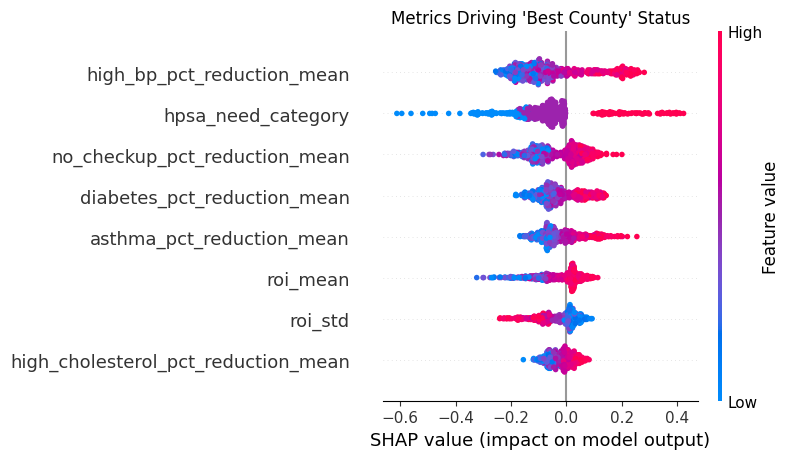

In [8]:
# --- STAGE 3: THE DEFINITIVE SHAP FIX ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# THE KEY FIX: We explicitly select the 2nd index [1] for Class 1 ("Best").
# If we pass the whole list, SHAP defaults to the interaction grid (2 features).
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] 
else:
    # Some SHAP versions return a 3D array; we slice for class 1
    shap_to_plot = shap_values[:,:,1] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_to_plot, X_test, plot_type="dot", show=False)
plt.title("Metrics Driving 'Best County' Status")
plt.tight_layout()
wandb.log({"shap_summary_plot": wandb.Image(plt)})
plt.show()

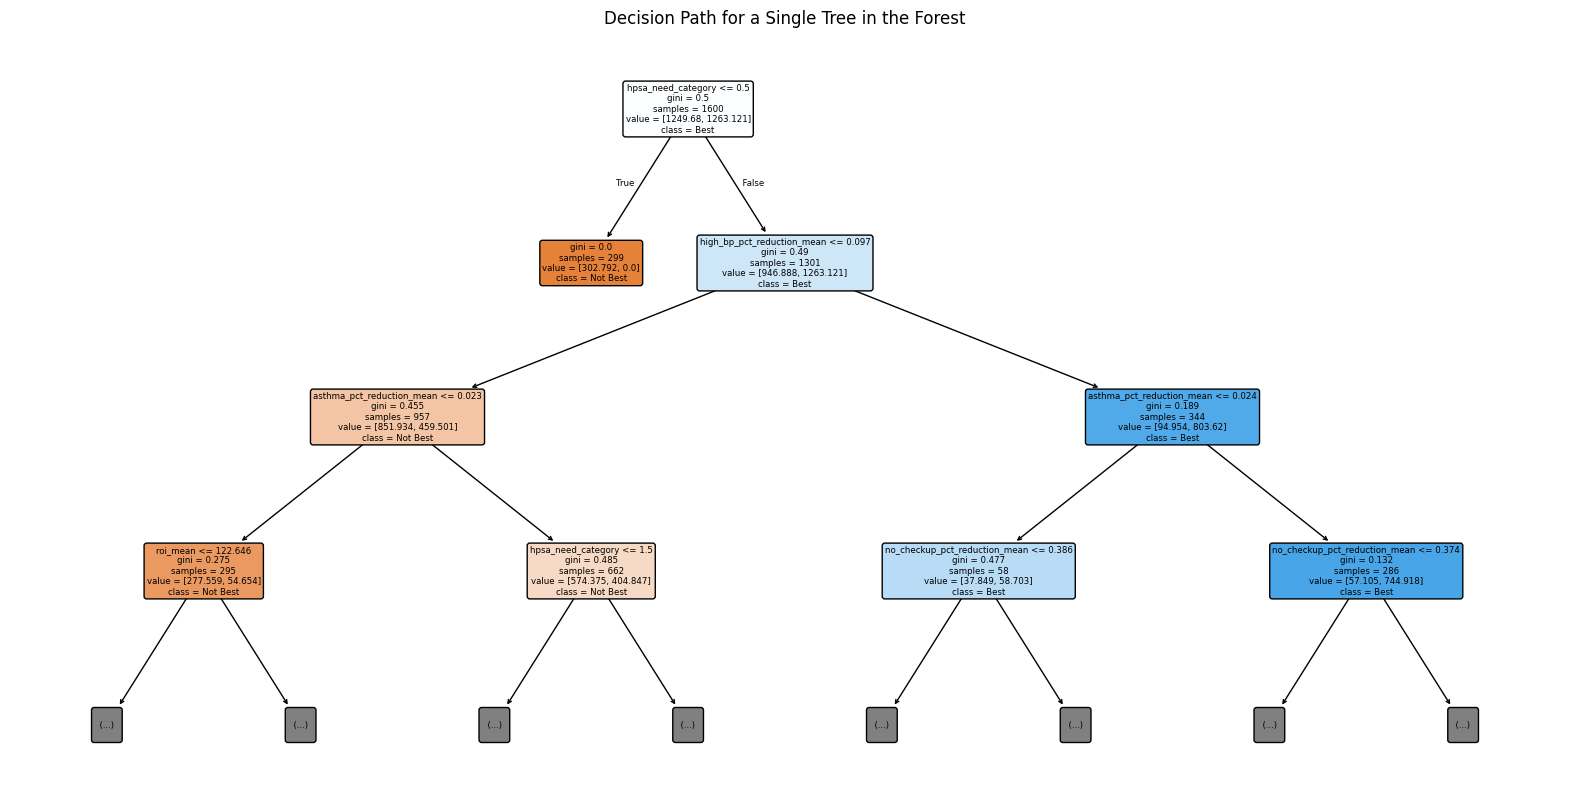

In [9]:
# --- STAGE 4: DECISION TREE VISUALIZATION ---
# We pick the first tree (index 0) from the forest to visualize
plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0], 
    feature_names=features, 
    class_names=["Not Best", "Best"], 
    filled=True, 
    rounded=True, 
    max_depth=3 # Limiting depth so it's readable
)
plt.title("Decision Path for a Single Tree in the Forest")
wandb.log({"decision_tree_plot": wandb.Image(plt)})
plt.show()

In [10]:
# --- STAGE 5: FLOURISH EXPORT & ARTIFACT LOGGING ---
county_df['fips_code'] = county_df['geoid'].astype(str).str.zfill(5)
export_df = county_df[['fips_code', 'county', 'state', 'is_best', 'composite_score', 'roi_mean', 'roi_std', 'hpsa_need_category'] + health_cols]
csv_path = 'counties_for_flourish.csv'
export_df.to_csv(csv_path, index=False)

artifact = wandb.Artifact('flourish_data', type='dataset')
artifact.add_file(csv_path)
wandb.log_artifact(artifact)

wandb.finish()
print("Process Complete. Confusion matrix and analysis logged to wandb.")

accuracy,▁
best_class_precision,▁
best_class_recall,▁
accuracy,0.96491
best_class_precision,0.96053
best_class_recall,0.90123


Process Complete. Confusion matrix and analysis logged to wandb.
